In [19]:
from typing import Tuple, Dict, List, Union, Optional
from meteostat import Stations
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys

In [20]:
sys.path.append('Utils/')
from PlotUtils import setMplParam, getColour, getHistoParam 
setMplParam()

In [21]:
# LAND_COLOUR = '#EFCA08'
LAND_COLOUR = '#EFDFBB' # Dutch White
OCEAN_COLOUR = '#1E90FF' # Dodger Blue
LAKE_RIVER_COLOUR = '#00CCFF' # Vivid Skyblue

In [22]:
def load_station_locations(
        bbox: Tuple[float, float, float, float],   # (lat_min, lat_max, lon_min, lon_max)
        )-> Dict[str, Tuple[float, float]]:
    
    lat_min, lat_max, lon_min, lon_max = bbox
    top_left = (lat_max, lon_min)
    bottom_right = (lat_min, lon_max)

    stations_in_region = Stations().bounds(top_left, bottom_right).fetch()
    station_locations = {row['name']: (row['longitude'], row['latitude']) for idx, row in stations_in_region.iterrows()}
    return station_locations
    


In [23]:
def caluculate_visualisation_params(
        bbox: Tuple[float, float, float, float],   # (lat_min, lat_max, lon_min, lon_max)
        )-> Dict[str, Tuple[float, float]]:
    lat_min, lat_max, lon_min, lon_max = bbox
    lat_range = lat_max - lat_min
    lon_range = lon_max - lon_min
    BASE = 7.5
    POWER = 0.3
    figsize_x = BASE * lon_range**POWER
    figsize_y = BASE * lat_range**POWER
    return (figsize_x, figsize_y)

In [24]:
def region_map(
    bbox: Tuple[float, float, float, float],   # (lat_min, lat_max, lon_min, lon_max)
    points: Optional[Union[Dict[str, Tuple[float, float]], List[Tuple[float, float]]]] = None,
    borders_scale: str = "110m",
    show_labels: bool = True,
    ocean_color: Optional[str] = OCEAN_COLOUR,
    land_color: Optional[str] = LAND_COLOUR,
    lake_river_color: Optional[str] = LAKE_RIVER_COLOUR,
):
    lat_min, lat_max, lon_min, lon_max = bbox

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=caluculate_visualisation_params(bbox))
    ax = plt.axes(projection=proj)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # Base features (custom colours)
    if ocean_color:
        ax.add_feature(cfeature.OCEAN.with_scale(borders_scale), zorder=0, facecolor=ocean_color)
    else:
        ax.add_feature(cfeature.OCEAN.with_scale(borders_scale), zorder=0)

    if land_color:
        ax.add_feature(cfeature.LAND.with_scale(borders_scale), zorder=1, facecolor=land_color, edgecolor="none")
    else:
        ax.add_feature(cfeature.LAND.with_scale(borders_scale), zorder=1)

    if lake_river_color:
        lakes = cfeature.NaturalEarthFeature("physical", "lakes", borders_scale, edgecolor="none", facecolor=lake_river_color)
        ax.add_feature(lakes, zorder=2)
        rivers = cfeature.NaturalEarthFeature("physical", "rivers_lake_centerlines", borders_scale, edgecolor=lake_river_color, facecolor="none")
        ax.add_feature(rivers, linewidth=1, zorder=3)
    else:
        lakes = cfeature.NaturalEarthFeature("physical", "lakes", borders_scale, edgecolor="none", facecolor="lightblue")
        ax.add_feature(lakes, zorder=2)
        rivers = cfeature.NaturalEarthFeature("physical", "rivers_lake_centerlines", borders_scale, edgecolor="lightblue", facecolor="none")
        ax.add_feature(rivers, linewidth=1, zorder=3)
    
    ax.coastlines(resolution=borders_scale, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale(borders_scale), linewidth=0.6)

    # Country outlines
    countries = cfeature.NaturalEarthFeature("cultural", "admin_0_countries", borders_scale, edgecolor="black", facecolor="none")
    ax.add_feature(countries, linewidth=0.3, zorder=3.5)

    # Points
    if points:
        items = points.items() if isinstance(points, dict) else [(f"P{i}", p) for i, p in enumerate(points, 1)]
        for name, (lat, lon) in items:
            ax.plot(lat, lon, "o", transform=proj, markersize=5, zorder=4, color=getColour(2))
            if show_labels:
                ax.text(lat, lon, f" {name}", transform=proj, fontsize=8, ha="left", va="bottom", zorder=4)

    gl = ax.gridlines(draw_labels=True, linewidth=1.0, linestyle="--")
    gl.right_labels = False
    gl.top_labels = False

    plt.tight_layout()
    plt.show()

In [25]:
def region_map_with_stations(
    bbox: Tuple[float, float, float, float],   # (lon_min, lon_max, lat_min, lat_max)
    borders_scale: str = "110m",
    show_labels: bool = True,
    ocean_color: Optional[str] = OCEAN_COLOUR,
    land_color: Optional[str] = LAND_COLOUR,
    lake_river_color: Optional[str] = LAKE_RIVER_COLOUR,
):
    station_locations = load_station_locations(bbox)
    region_map(bbox=bbox, 
               points=station_locations, 
               borders_scale=borders_scale, 
               show_labels=show_labels,
               ocean_color=ocean_color, 
               land_color=land_color, 
               lake_river_color=lake_river_color)

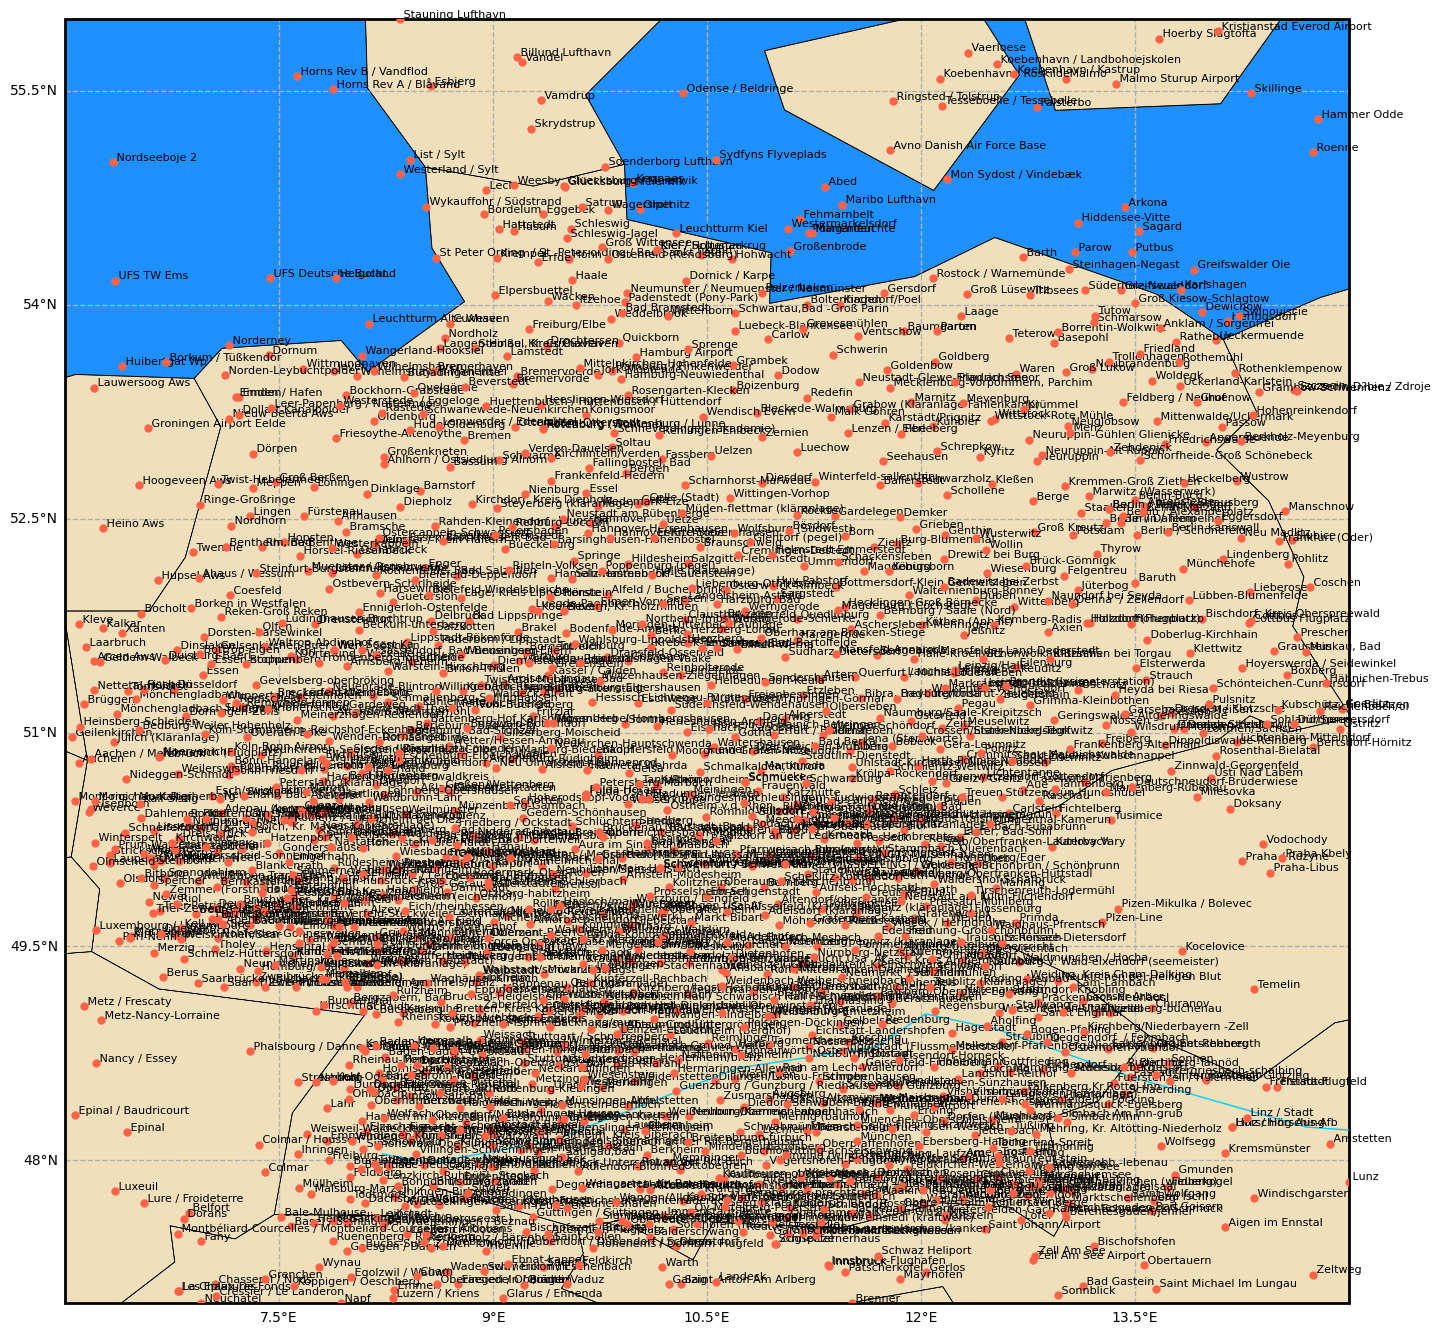

In [26]:
# Germany 15 sec
region_map_with_stations(bbox=(47.0, 56.0, 6, 15),
                         borders_scale="110m", 
                         show_labels=True)
# 

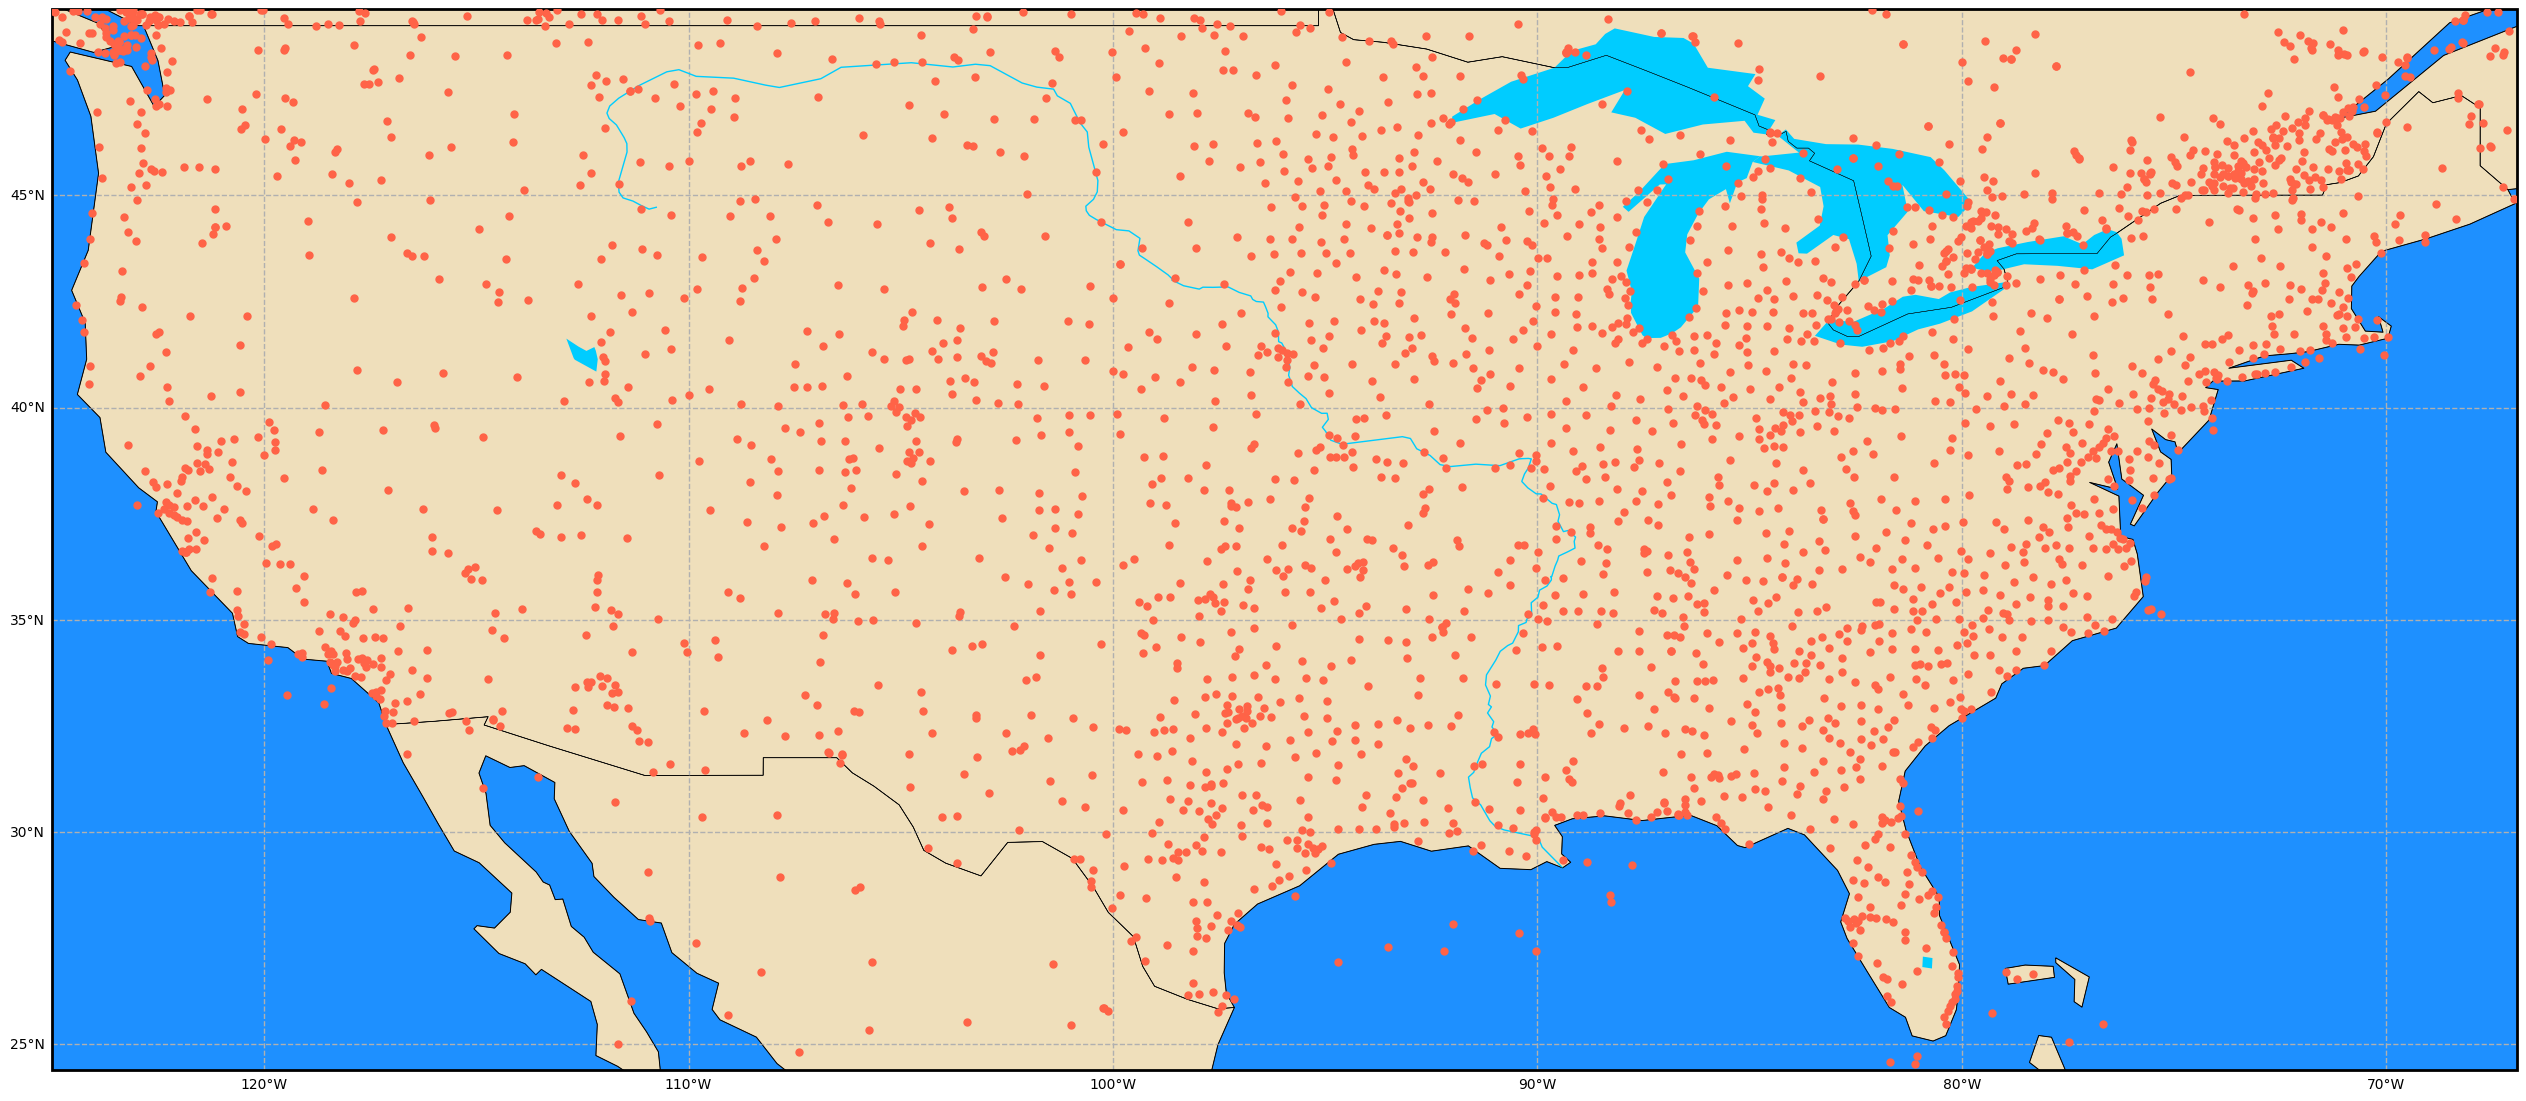

In [27]:
# The USA 10 sec
region_map_with_stations(bbox=(24.396308, 49.384358, -125.0, -66.93457),
                         borders_scale="110m", 
                         show_labels=False)


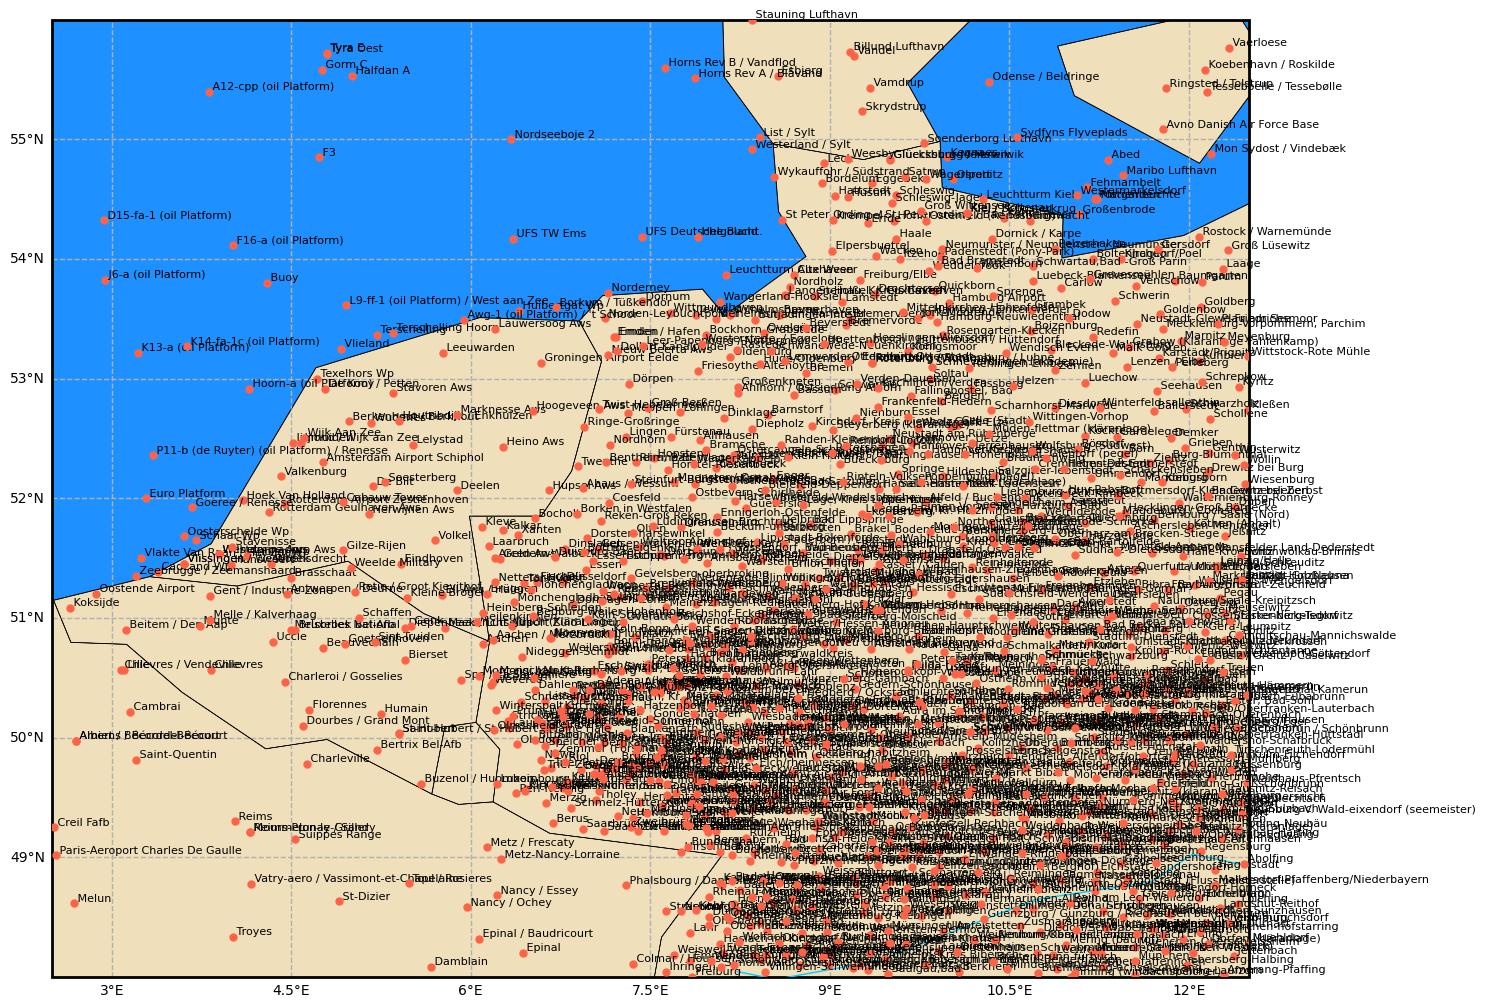

In [28]:
# Germania Inferior 20 sec
region_map_with_stations(bbox=(48.0, 56.0, 2.5, 12.5), 
                         borders_scale="110m", 
                         show_labels=True)
# 

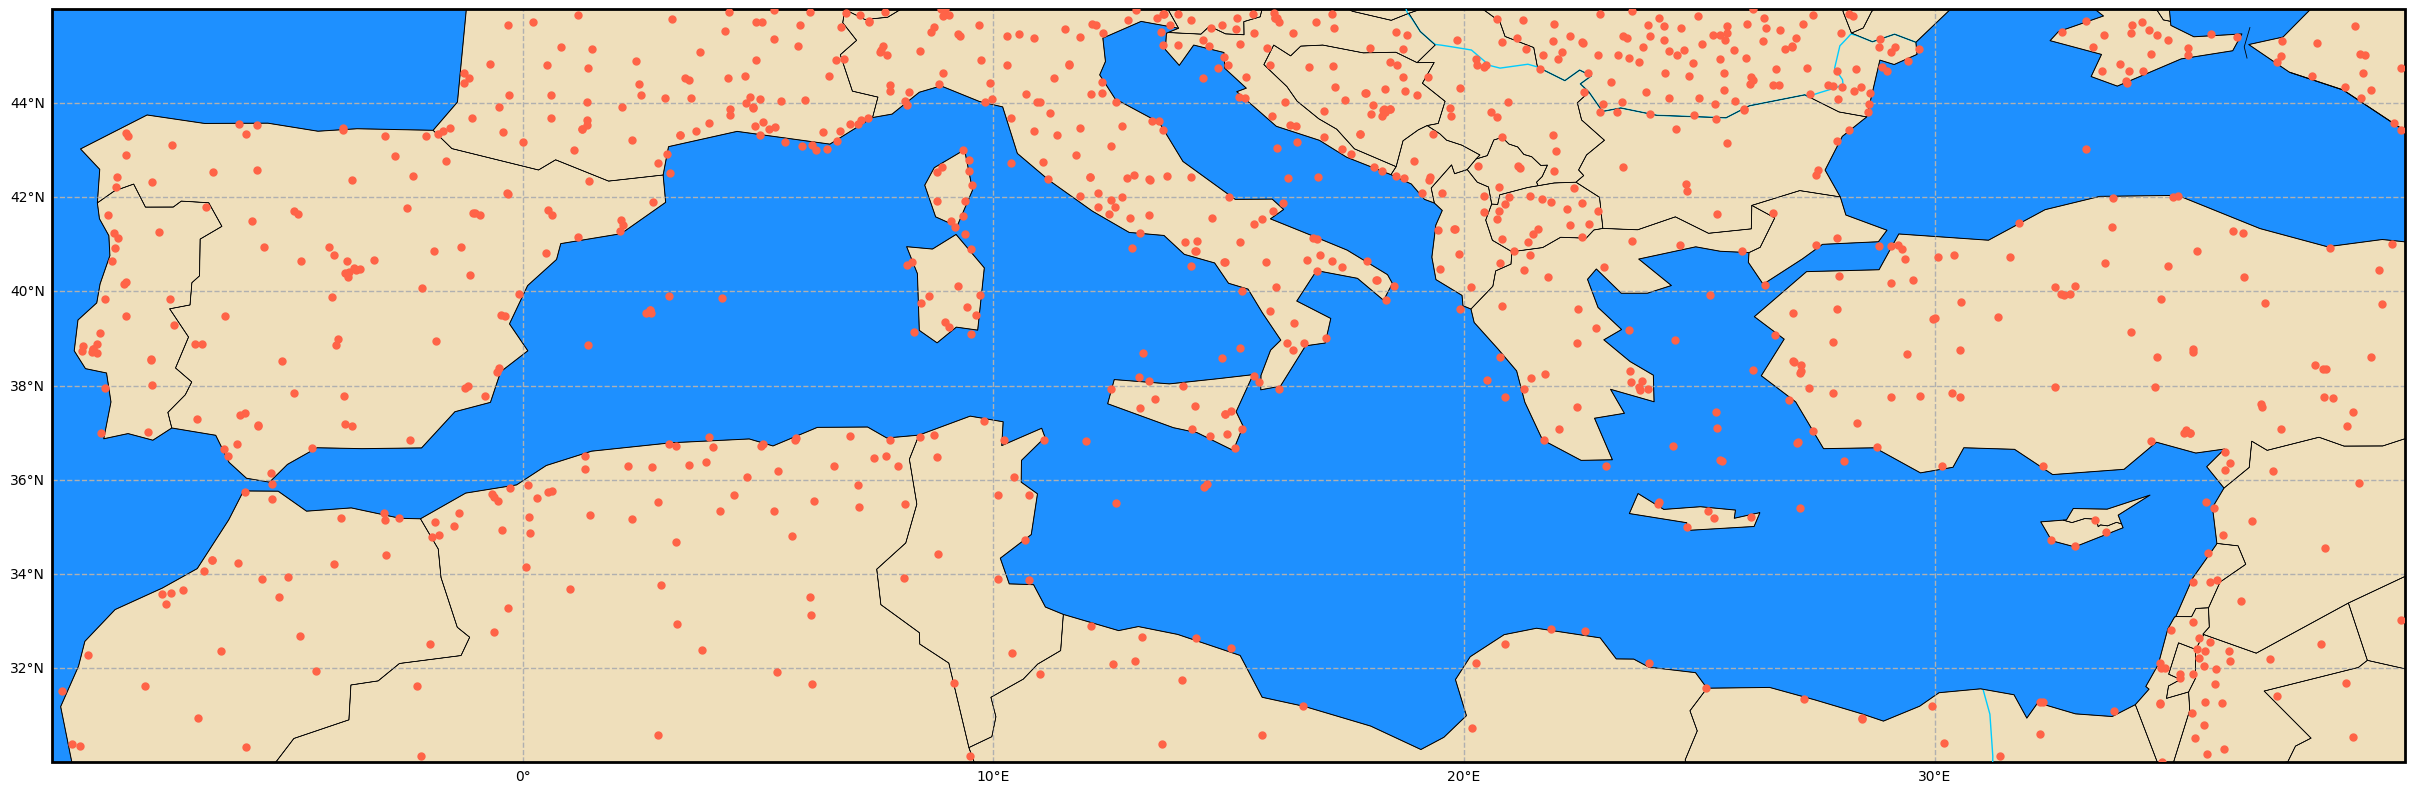

In [29]:
# Mediterranean 10 sec
region_map_with_stations(bbox=(30.0, 46.0, -10.0, 40.0), 
                         borders_scale="110m", 
                         show_labels=False)

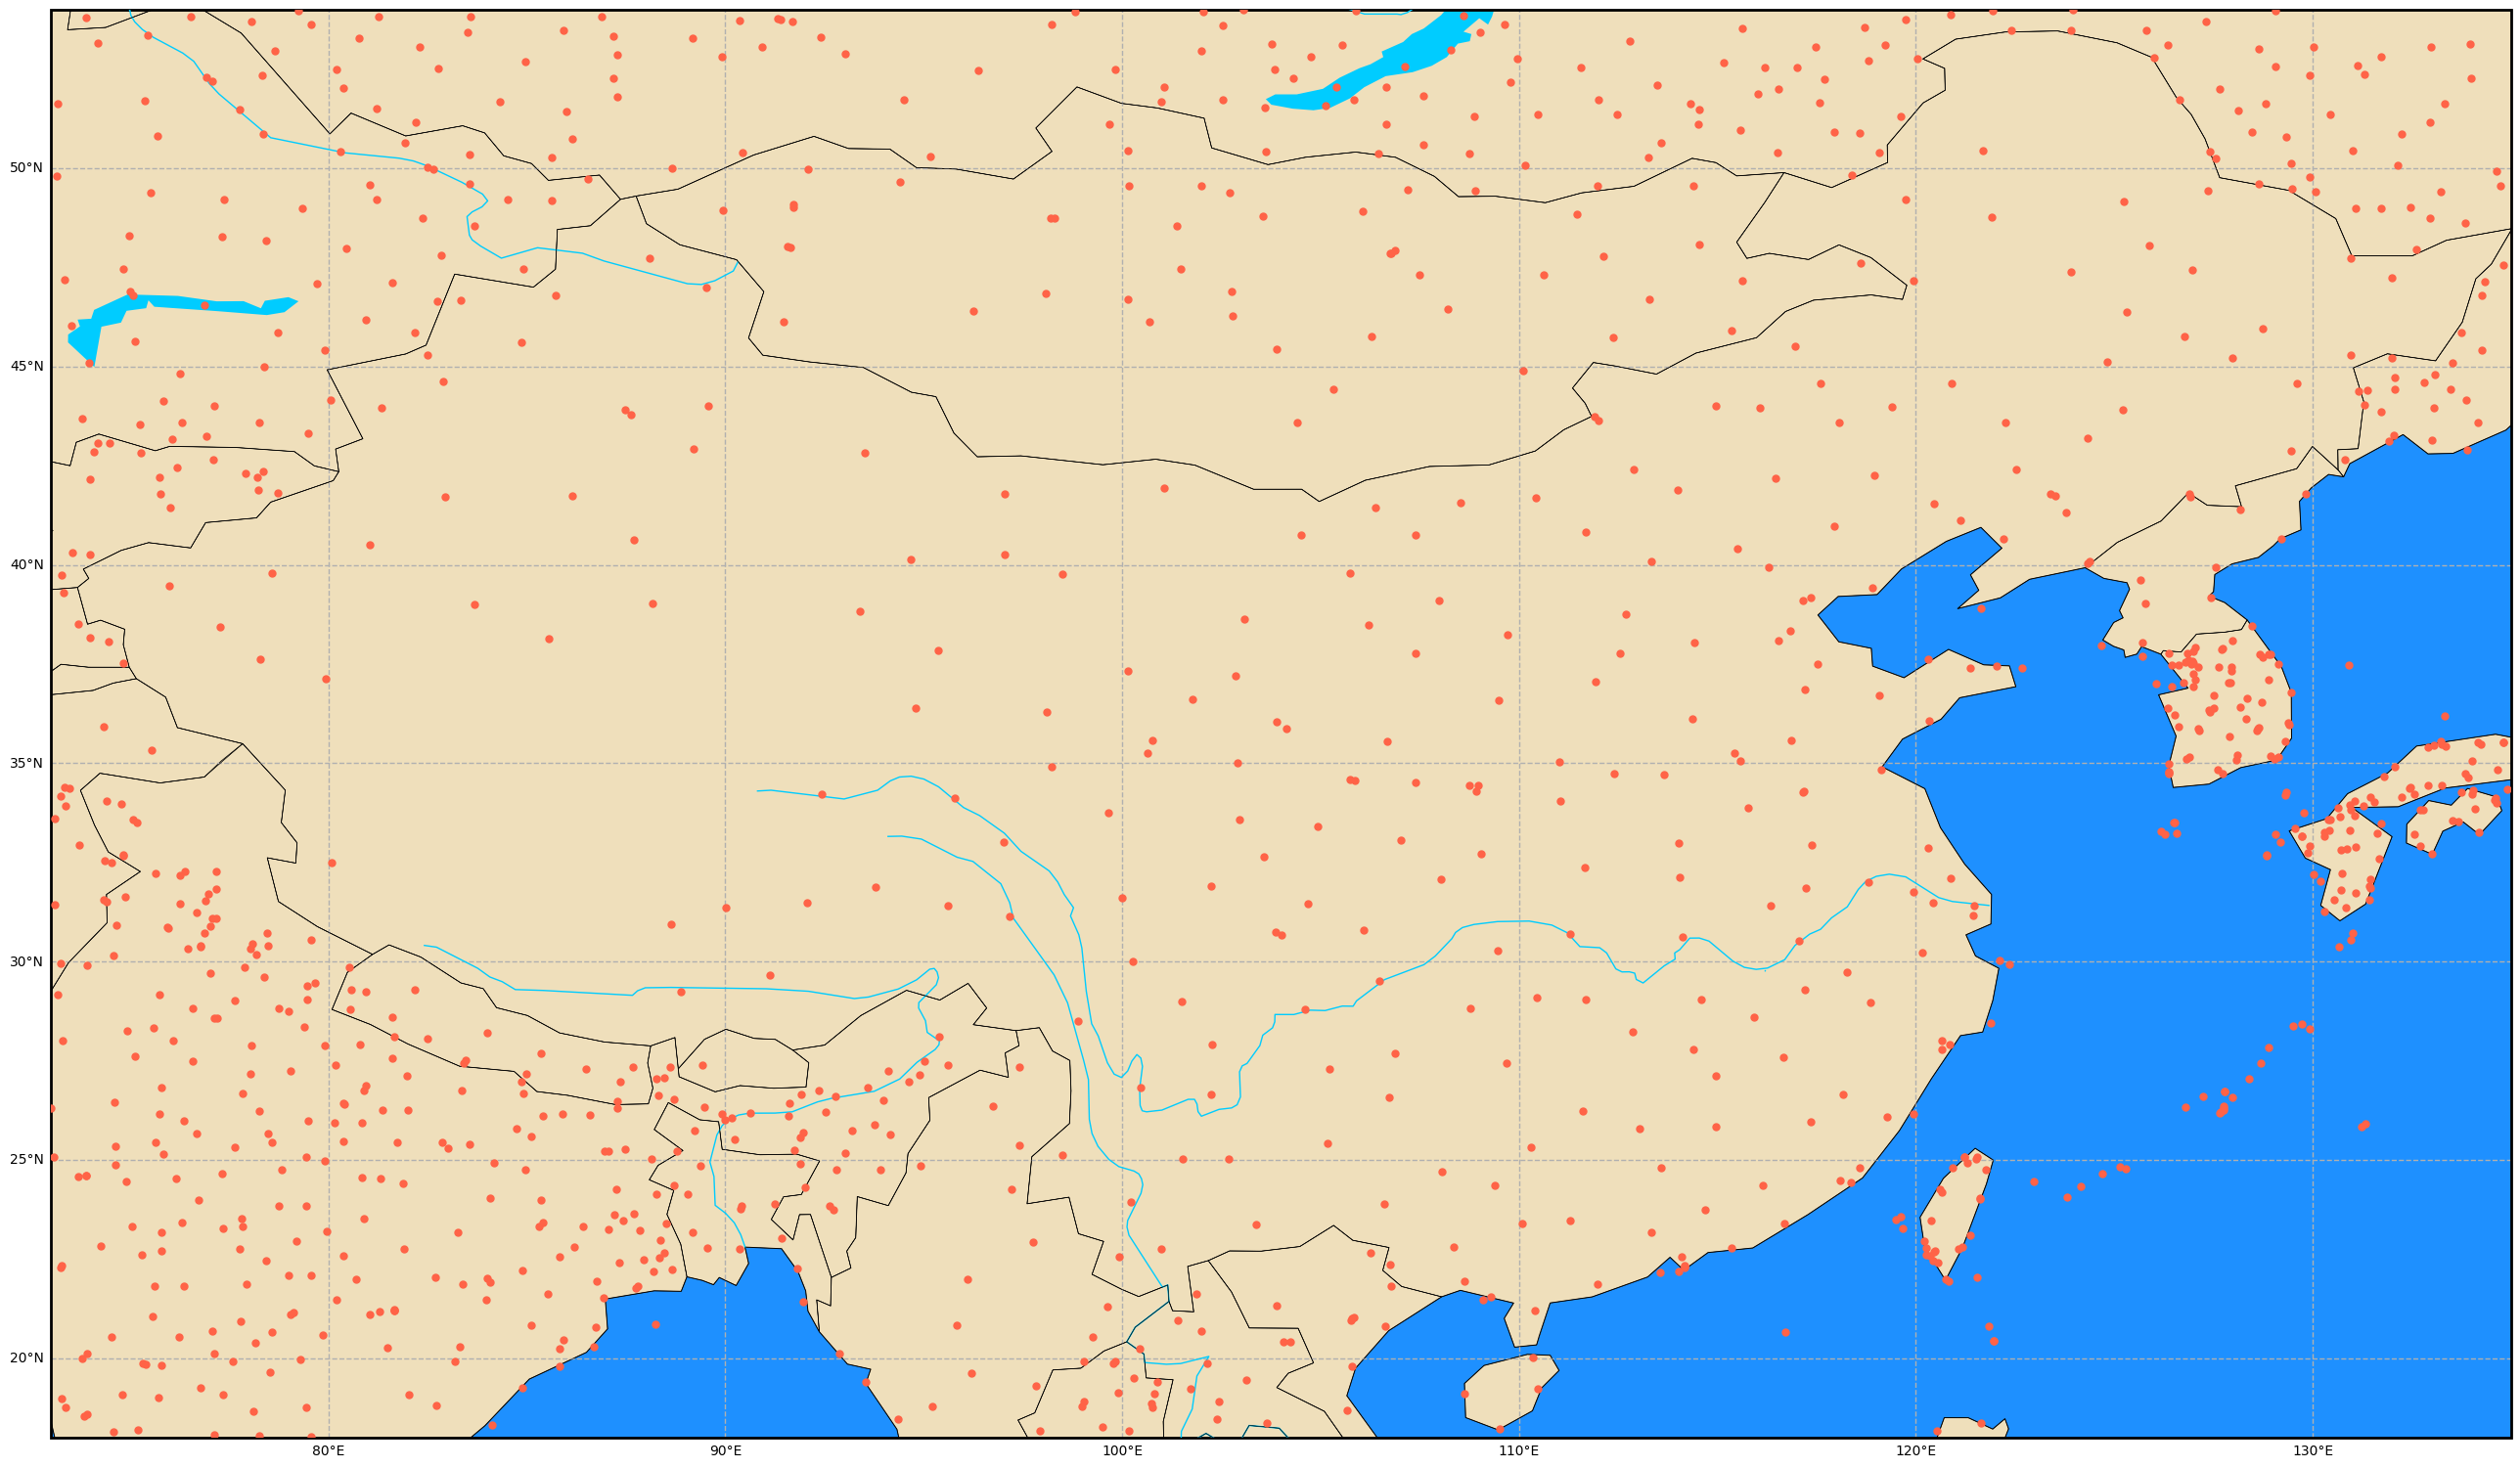

In [30]:
# China 10 sec
region_map_with_stations(bbox=(18.0, 54.0, 73.0, 135.0), 
                         borders_scale="110m", 
                         show_labels=False)

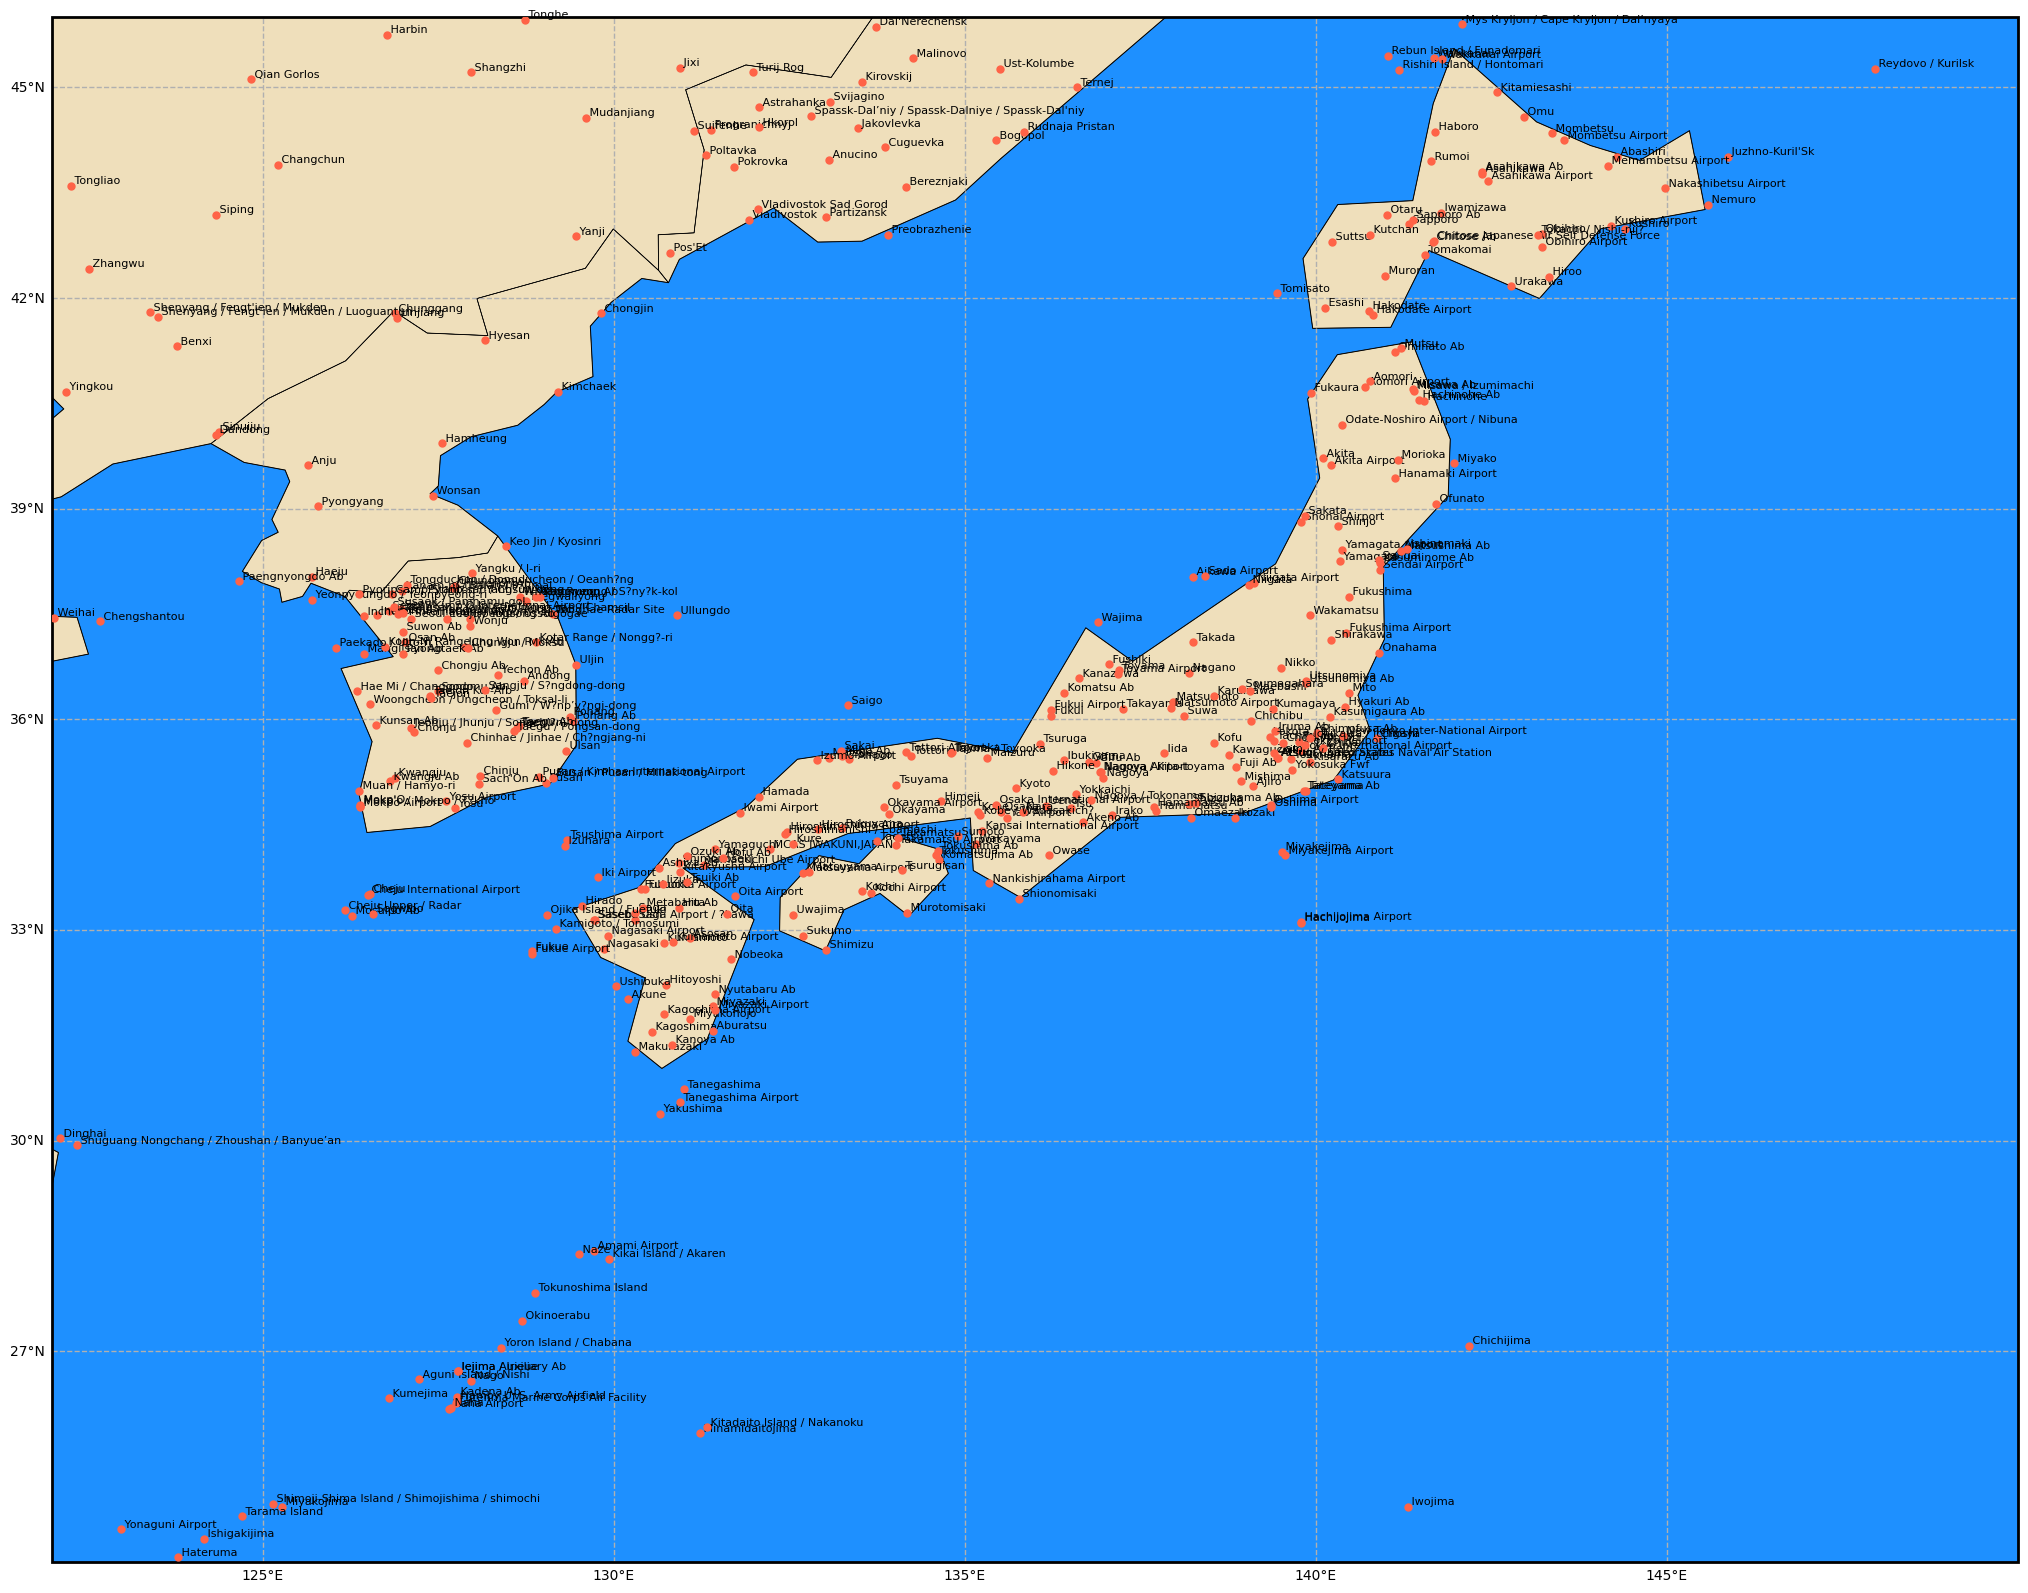

In [31]:
# Korea-Japan 6 sec
region_map_with_stations(bbox=(24.0, 46.0, 122.0, 150.0), 
                         borders_scale="110m", 
                         show_labels=True)

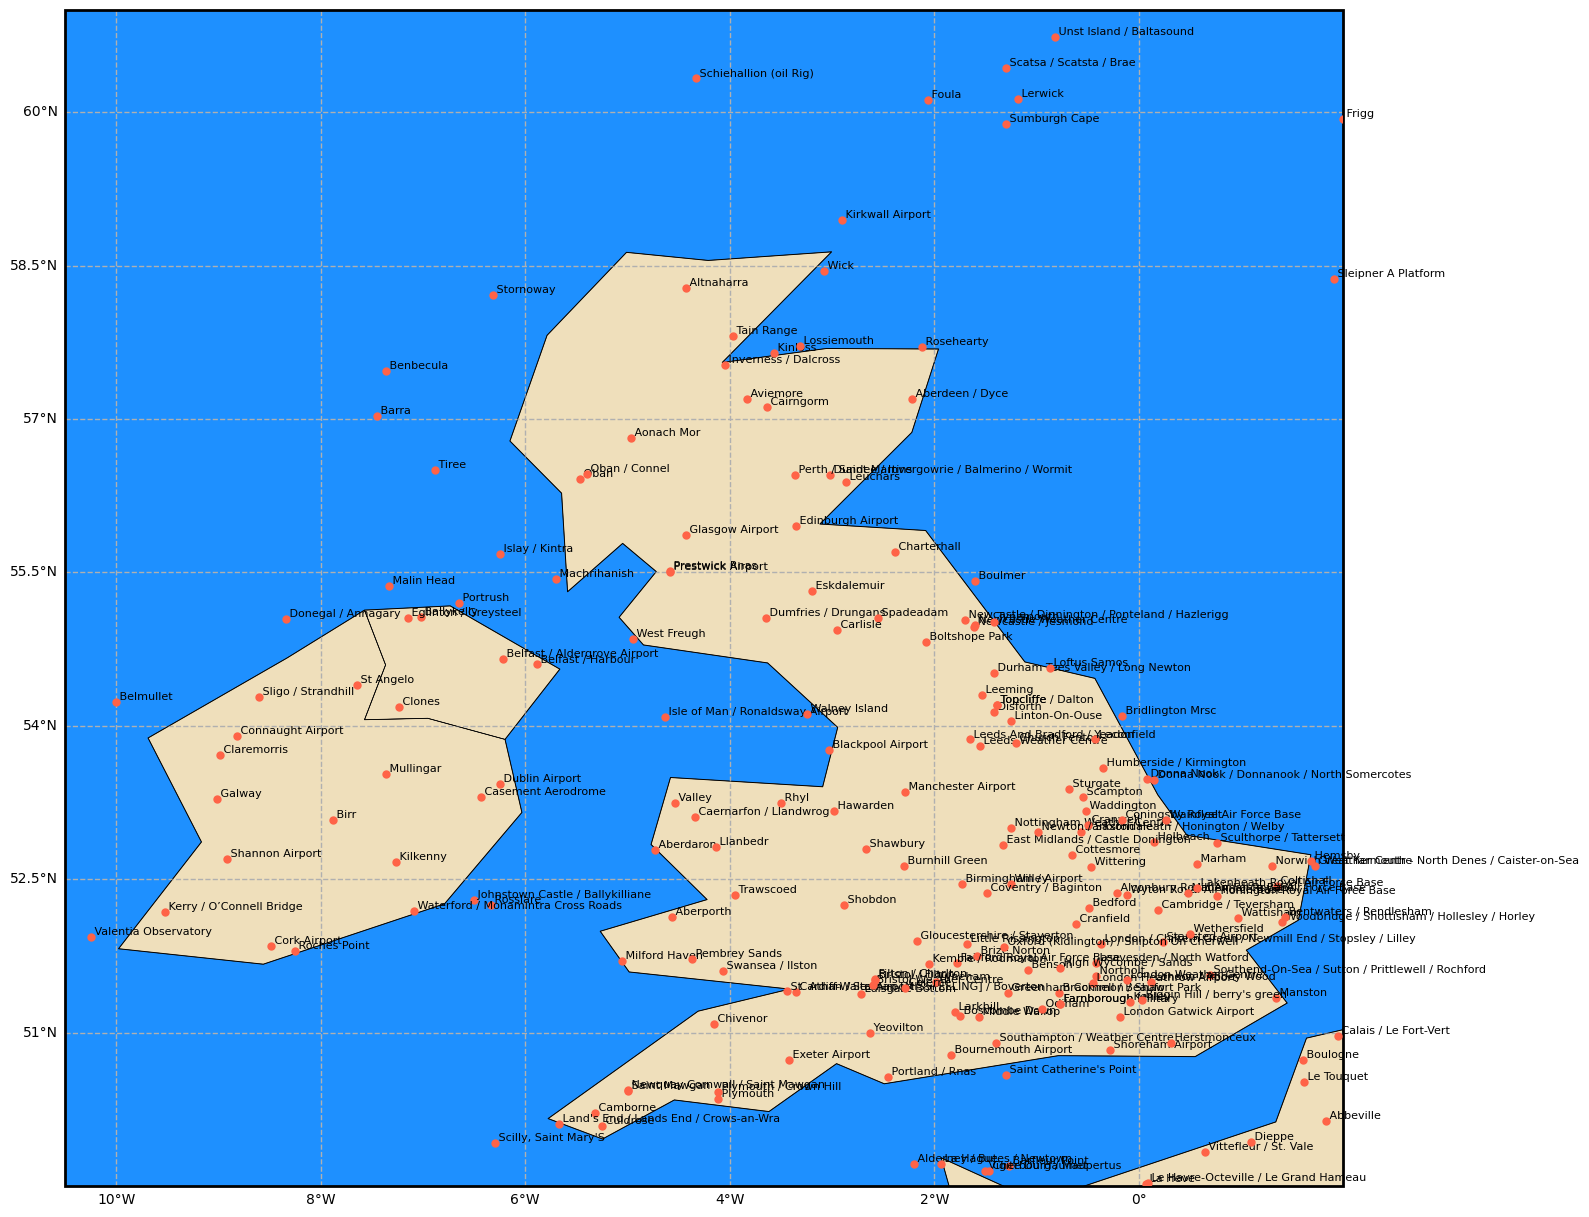

In [32]:
# UK 10 sec
region_map_with_stations(bbox=(49.5, 61.0, -10.5, 2.0), 
                         borders_scale="110m", 
                         show_labels=True)

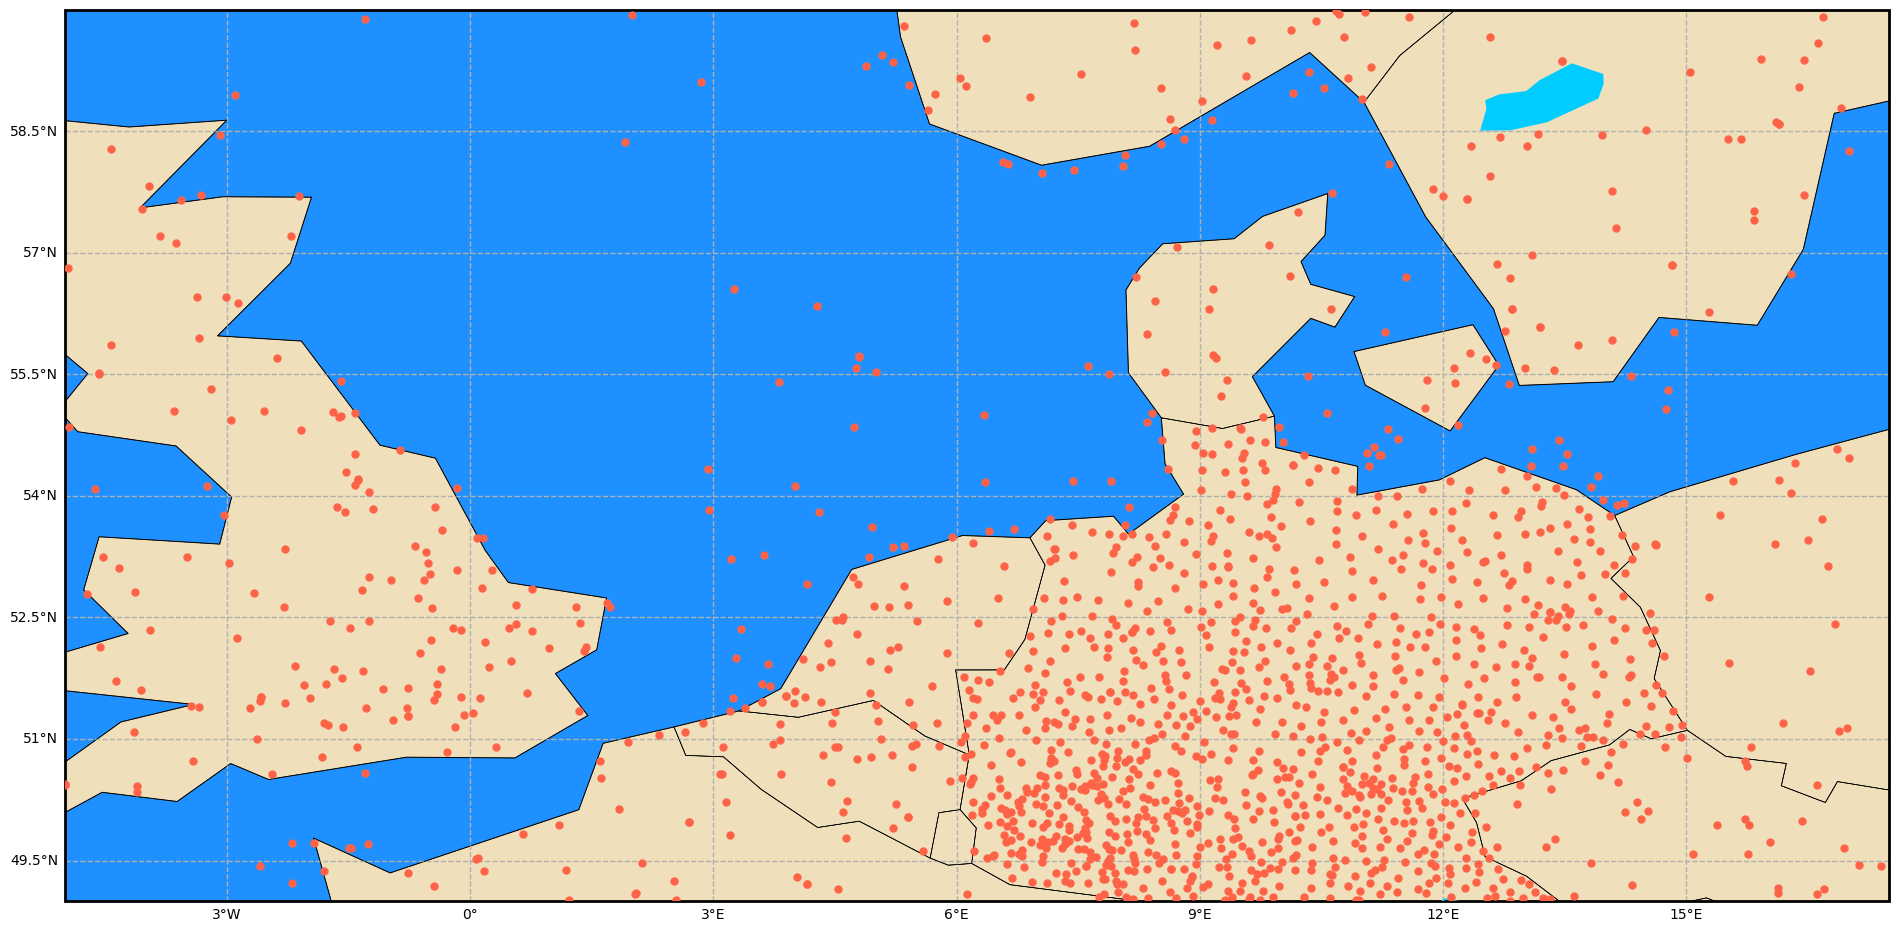

In [33]:
# north west Europe 10 sec
region_map_with_stations(bbox=(49.0, 60.0, -5.0, 17.5), 
                         borders_scale="110m", 
                         show_labels=False)